# PHARAOH-Guard: Intelligent Crowd Management & Heritage Protection System
## Notebook 02 — Data Cleaning & Quality Validation

**Pipeline stage:** 02 of 06
**Input:** `pharaoh_guard_dataset.csv` (from Notebook 01)
**Output:** `pharaoh_guard_clean.csv`, `quality_report.json`

---

### 1. Purpose

Notebook 01 generated a synthetic dataset with realistic business logic baked in, which means it is largely self-consistent by construction. However, **a production pipeline must never assume its input is clean** — this notebook runs the same defensive validation suite that would be applied to a real operational data feed, so that:

1. Any future replacement of the synthetic generator with a real data connector requires **no changes to this notebook**
2. The next team downstream (Feature Engineering, then the Generative AI team) can trust the output without re-verifying it themselves

### 2. What This Notebook Checks

| Check | Action if issues are found |
|---|---|
| Data type validation | Coerce to correct dtype (datetime, category, int8 for flags) |
| Missing values | Impute (median for numeric, mode for categorical) or drop, logged either way |
| Duplicate records | Drop exact duplicates and duplicate (site, timestamp) keys |
| Invalid categories | Flag any value outside the known allowed set per categorical column |
| Feature/logical consistency | Cross-check derived fields (e.g. `Occupancy_Rate` vs `Current_Visitors / Site_Capacity`, `Weekend` vs `Day_of_Week`) |
| Outlier detection | Report via IQR — **not** blindly removed, since extreme values here often represent genuine high-risk events that the model needs to learn from |

A full machine-readable **Data Quality Report** is generated at the end for audit purposes.


## 1. Imports & Load Raw Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

INPUT_PATH = "../data/pharaoh_guard_dataset.csv"
df = pd.read_csv(INPUT_PATH)

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns from {INPUT_PATH}")
df.head()


Loaded 55,480 rows, 35 columns from ../data/pharaoh_guard_dataset.csv


,Timestamp,Date,Month,Season,Day_of_Week,Weekend,Holiday,Hour,Site_Name,Site_Capacity,...,Queue_Time,Occupancy_Rate,Crowd_Density,Weather_Score,Security_Score,Site_Sensitivity,Operational_Load,Risk_Score,Risk_Level,Recommendation
0,2023-01-01T08:00:00,2023-01-01,1,Winter,Sunday,0,1,8,Giza Pyramids,15000,...,21.8,0.5007,0.4481,0.8688,0.1757,0.65,0.6490,48.83,Medium,"Monitor crowd flow closely, prepare standby se..."
1,2023-01-01T09:00:00,2023-01-01,1,Winter,Sunday,0,1,9,Giza Pyramids,15000,...,38.5,0.6534,0.5848,0.7447,0.1306,0.65,0.7244,57.46,High,"Deploy additional security staff, open extra e..."
2,2023-01-01T10:00:00,2023-01-01,1,Winter,Sunday,0,1,10,Giza Pyramids,15000,...,98.3,1.0992,0.9838,0.8180,0.0776,0.65,0.9330,74.70,Critical,Activate emergency protocol: deploy additional...
3,2023-01-01T11:00:00,2023-01-01,1,Winter,Sunday,0,1,11,Giza Pyramids,15000,...,71.6,0.8538,0.7642,0.8732,0.0906,0.65,0.8206,64.07,High,"Deploy additional security staff, open extra e..."
4,2023-01-01T12:00:00,2023-01-01,1,Winter,Sunday,0,1,12,Giza Pyramids,15000,...,62.8,1.1500,1.0292,0.7907,0.0649,0.65,0.9578,77.32,Critical,Activate emergency protocol: deploy additional...


In [2]:
quality_report = {
    "generated_at": datetime.now().isoformat(),
    "input_file": INPUT_PATH,
    "input_rows": int(len(df)),
    "checks": {},
}
print("Quality report initialized.")


Quality report initialized.


## 2. Data Type Validation

Raw CSV loading defaults everything that isn't purely numeric to plain strings/objects. We enforce the correct types explicitly:
- `Timestamp` → `datetime64`
- Categorical text columns → `category` dtype (memory-efficient, and makes invalid-value checks trivial)
- Binary flag columns (0/1) → `int8` (no need for full 64-bit ints)


In [3]:
dtype_issues = []

before_dtypes = df.dtypes.astype(str).to_dict()

try:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
except Exception as e:
    dtype_issues.append(f"Timestamp parse failed: {e}")

try:
    df["Date"] = pd.to_datetime(df["Date"]).dt.date
except Exception as e:
    dtype_issues.append(f"Date parse failed: {e}")

CATEGORICAL_COLS = ["Season", "Day_of_Week", "Site_Name", "Emergency_Type", "Risk_Level"]
for c in CATEGORICAL_COLS:
    df[c] = df[c].astype("category")

BINARY_COLS = ["Weekend", "Holiday", "Special_Events", "VIP_Visits", "School_Trips"]
for c in BINARY_COLS:
    df[c] = df[c].astype("int8")

after_dtypes = df.dtypes.astype(str).to_dict()

quality_report["checks"]["dtype_validation"] = {
    "issues_found": dtype_issues,
    "columns_converted": len(CATEGORICAL_COLS) + len(BINARY_COLS) + 2,
}

print("Dtype issues found:", dtype_issues if dtype_issues else "None")
print()
print("Final dtypes:")
print(df.dtypes)


Dtype issues found: None

Final dtypes:
Timestamp           datetime64[us]
Date                        object
Month                        int64
Season                    category
Day_of_Week               category
Weekend                       int8
Holiday                       int8
Hour                         int64
Site_Name                 category
Site_Capacity                int64
Current_Visitors             int64
Entry_Gates                  int64
Exit_Gates                   int64
Security_Staff               int64
Medical_Team                 int64
Police_Units                 int64
Temperature                float64
Humidity                   float64
Wind_Speed                 float64
Visibility                 float64
Special_Events                int8
VIP_Visits                    int8
School_Trips                  int8
Emergency_Type            category
Queue_Length                 int64
Queue_Time                 float64
Occupancy_Rate             float64
Crowd_Density  

## 3. Missing Values

Even though the generator produces complete data, this section is written defensively: numeric columns are median-imputed and categorical columns are mode-imputed **only if** missing values are actually present, so the logic is real and would activate against a genuinely incomplete feed.

In [4]:
missing_before = df.isna().sum()
missing_cols = missing_before[missing_before > 0]

imputation_log = {}
if len(missing_cols) > 0:
    for col in missing_cols.index:
        if pd.api.types.is_numeric_dtype(df[col]):
            fill_value = df[col].median()
            df[col] = df[col].fillna(fill_value)
            imputation_log[col] = {"strategy": "median", "value": float(fill_value)}
        else:
            fill_value = df[col].mode()[0]
            df[col] = df[col].fillna(fill_value)
            imputation_log[col] = {"strategy": "mode", "value": str(fill_value)}
    print(f"Imputed {len(missing_cols)} columns with missing values:")
    print(missing_cols)
else:
    print("No missing values found - no imputation needed.")

quality_report["checks"]["missing_values"] = {
    "columns_with_missing_before": missing_cols.to_dict(),
    "imputation_applied": imputation_log,
    "missing_after": int(df.isna().sum().sum()),
}

assert df.isna().sum().sum() == 0, "Missing values remain after cleaning step"
print("\nConfirmed: 0 missing values remain.")


No missing values found - no imputation needed.

Confirmed: 0 missing values remain.


## 4. Duplicate Records

We check both exact full-row duplicates and duplicate (`Site_Name`, `Timestamp`) keys — the latter would indicate two conflicting readings for the same site at the same hour, which is a business-logic impossibility, not just a data artifact.

In [5]:
n_before = len(df)

full_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=["Site_Name", "Timestamp"]).sum()

df = df.drop_duplicates()
df = df.drop_duplicates(subset=["Site_Name", "Timestamp"], keep="first")

n_after = len(df)

quality_report["checks"]["duplicates"] = {
    "full_row_duplicates_found": int(full_dupes),
    "site_timestamp_key_duplicates_found": int(key_dupes),
    "rows_removed": int(n_before - n_after),
}

print(f"Full-row duplicates found: {full_dupes}")
print(f"(Site, Timestamp) key duplicates found: {key_dupes}")
print(f"Rows removed: {n_before - n_after}")
print(f"Row count: {n_before:,} -> {n_after:,}")


Full-row duplicates found: 0
(Site, Timestamp) key duplicates found: 0
Rows removed: 0
Row count: 55,480 -> 55,480


## 5. Invalid Category Detection

Each categorical column is validated against its known allowed value set. Any row with a value outside this set would be flagged for review rather than silently dropped, since an unexpected category in a real feed (e.g. a new site opening) is business-relevant information, not noise.

In [6]:
VALID_VALUES = {
    "Site_Name": {"Giza Pyramids", "Grand Egyptian Museum", "Saqqara", "Luxor Temple",
                  "Karnak Temple", "Abu Simbel", "Valley of the Kings", "Citadel of Cairo"},
    "Season": {"Winter", "Spring", "Summer", "Autumn"},
    "Day_of_Week": {"Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"},
    "Risk_Level": {"Low", "Medium", "High", "Critical"},
    "Emergency_Type": {"No_Emergency", "Medical", "Security", "Lost Person"},
}

invalid_category_report = {}
for col, valid_set in VALID_VALUES.items():
    invalid_mask = ~df[col].isin(valid_set)
    n_invalid = int(invalid_mask.sum())
    invalid_category_report[col] = n_invalid
    if n_invalid > 0:
        print(f"WARNING: {col} has {n_invalid} rows with unexpected values: "
              f"{df.loc[invalid_mask, col].unique()}")
        df = df[~invalid_mask]

quality_report["checks"]["invalid_categories"] = invalid_category_report

if sum(invalid_category_report.values()) == 0:
    print("All categorical columns contain only expected values.")
else:
    print(f"\nRemoved rows with invalid categories. New row count: {len(df):,}")


All categorical columns contain only expected values.


## 6. Feature / Logical Consistency Validation

Several columns are mathematically or logically derived from others. We cross-check these relationships hold, since a mismatch here would indicate a corrupted or tampered record rather than an outlier:

- `Occupancy_Rate` should equal `Current_Visitors / Site_Capacity` (within rounding tolerance)
- `Weekend` should be `1` if and only if `Day_of_Week` is Friday or Saturday (Egyptian weekend)
- `Current_Visitors` should never exceed 115% of `Site_Capacity` (the generator's hard ceiling)
- No count-based column (`Current_Visitors`, `Queue_Length`, `Queue_Time`, `Security_Staff`, etc.) should be negative


In [7]:
consistency_report = {}

recomputed_occ = (df["Current_Visitors"] / df["Site_Capacity"]).round(4)
occ_mismatch = (recomputed_occ - df["Occupancy_Rate"]).abs() > 0.001
consistency_report["occupancy_rate_mismatches"] = int(occ_mismatch.sum())

expected_weekend = df["Day_of_Week"].isin(["Friday", "Saturday"]).astype("int8")
weekend_mismatch = (expected_weekend.values != df["Weekend"].values)
consistency_report["weekend_flag_mismatches"] = int(weekend_mismatch.sum())

over_capacity = (df["Current_Visitors"] > df["Site_Capacity"] * 1.15)
consistency_report["over_capacity_records"] = int(over_capacity.sum())

count_cols = ["Current_Visitors", "Queue_Length", "Queue_Time", "Security_Staff",
              "Medical_Team", "Police_Units", "Entry_Gates", "Exit_Gates"]
negative_counts = (df[count_cols] < 0).sum()
consistency_report["negative_value_columns"] = negative_counts[negative_counts > 0].to_dict()

# Fix any mismatches found (recompute from source-of-truth columns rather than dropping)
if occ_mismatch.sum() > 0:
    df.loc[occ_mismatch, "Occupancy_Rate"] = recomputed_occ[occ_mismatch]
if weekend_mismatch.sum() > 0:
    df.loc[weekend_mismatch, "Weekend"] = expected_weekend[weekend_mismatch].astype("int8")
if over_capacity.sum() > 0:
    df = df[~over_capacity]
if sum(consistency_report["negative_value_columns"].values() if consistency_report["negative_value_columns"] else [0]) > 0:
    for c in count_cols:
        df = df[df[c] >= 0]

quality_report["checks"]["logical_consistency"] = consistency_report

print(json.dumps(consistency_report, indent=2))
print(f"\nRow count after consistency fixes: {len(df):,}")


{
  "occupancy_rate_mismatches": 0,
  "weekend_flag_mismatches": 0,
  "over_capacity_records": 0,
  "negative_value_columns": {}
}

Row count after consistency fixes: 55,480


## 7. Outlier Detection (Report, Not Blind Removal)

**Important judgment call:** these are operational risk variables. A record showing 12,000 visitors at a 15,000-capacity site during a national holiday isn't bad data — it's exactly the high-risk scenario PHARAOH-Guard exists to predict. Blindly stripping statistical outliers here would delete the rare `Critical` risk class the model most needs to learn.

Instead, we use the IQR method to **flag and quantify** outliers for transparency, and only act on outliers that also fail a hard business-logic bound (already handled in Section 6).


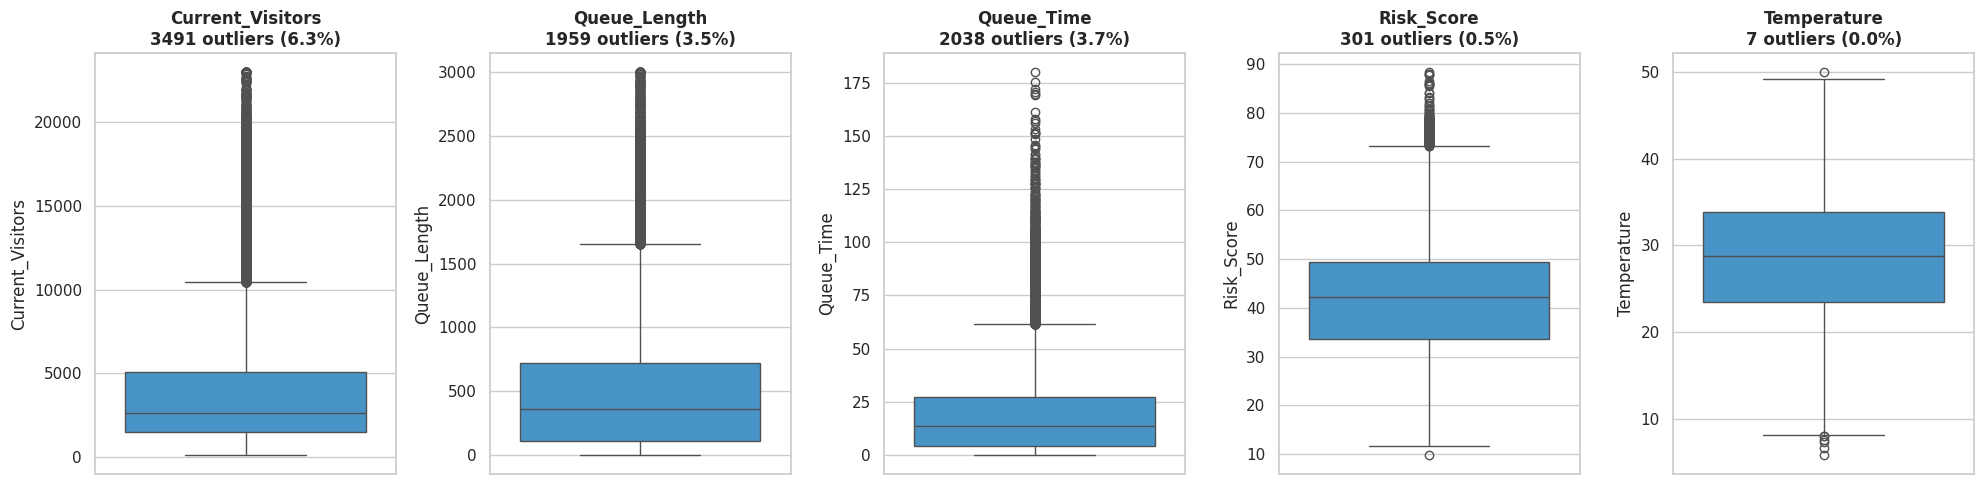

{
  "Current_Visitors": {
    "n_outliers": 3491,
    "pct_outliers": 6.29,
    "lower_bound": -3894.5,
    "upper_bound": 10445.5
  },
  "Queue_Length": {
    "n_outliers": 1959,
    "pct_outliers": 3.53,
    "lower_bound": -821.0,
    "upper_bound": 1651.0
  },
  "Queue_Time": {
    "n_outliers": 2038,
    "pct_outliers": 3.67,
    "lower_bound": -30.15,
    "upper_bound": 61.45
  },
  "Risk_Score": {
    "n_outliers": 301,
    "pct_outliers": 0.54,
    "lower_bound": 9.9,
    "upper_bound": 73.26
  },
  "Temperature": {
    "n_outliers": 7,
    "pct_outliers": 0.01,
    "lower_bound": 8.05,
    "upper_bound": 49.25
  }
}


In [8]:
numeric_check_cols = ["Current_Visitors", "Queue_Length", "Queue_Time", "Risk_Score", "Temperature"]
outlier_report = {}

fig, axes = plt.subplots(1, len(numeric_check_cols), figsize=(20, 5))
for ax, col in zip(axes, numeric_check_cols):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_report[col] = {
        "n_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(df) * 100, 2),
        "lower_bound": round(float(lower), 2),
        "upper_bound": round(float(upper), 2),
    }
    sns.boxplot(y=df[col], ax=ax, color="#3498db")
    ax.set_title(f"{col}\n{n_outliers} outliers ({n_outliers/len(df)*100:.1f}%)")

plt.tight_layout()
plt.savefig("../figures/02_outlier_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

quality_report["checks"]["outliers_iqr"] = outlier_report
print(json.dumps(outlier_report, indent=2))


In [9]:
# Cross-check: what fraction of IQR outliers in Risk_Score are actually High/Critical risk events?
# (this confirms outliers are meaningful signal, not noise, and justifies NOT removing them)
q1, q3 = df["Risk_Score"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
risk_outliers = df[df["Risk_Score"] > upper]

print(f"Risk_Score outliers (n={len(risk_outliers)}):")
print(risk_outliers["Risk_Level"].value_counts())
print(f"\n{(risk_outliers['Risk_Level'].isin(['High', 'Critical'])).mean()*100:.1f}% "
      f"of Risk_Score outliers are High/Critical risk events - confirms these are signal, not noise.")


Risk_Score outliers (n=300):
Risk_Level
Critical    300
High          0
Low           0
Medium        0
Name: count, dtype: int64

100.0% of Risk_Score outliers are High/Critical risk events - confirms these are signal, not noise.


## 8. Final Schema & Row Count Summary

In [10]:
print("Final cleaned dataset:")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {df.shape[1]}")
print(f"  Missing values: {df.isna().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")
print()
print(df.dtypes)


Final cleaned dataset:
  Rows: 55,480
  Columns: 35
  Missing values: 0
  Duplicate rows: 0

Timestamp           datetime64[us]
Date                        object
Month                        int64
Season                    category
Day_of_Week               category
Weekend                       int8
Holiday                       int8
Hour                         int64
Site_Name                 category
Site_Capacity                int64
Current_Visitors             int64
Entry_Gates                  int64
Exit_Gates                   int64
Security_Staff               int64
Medical_Team                 int64
Police_Units                 int64
Temperature                float64
Humidity                   float64
Wind_Speed                 float64
Visibility                 float64
Special_Events                int8
VIP_Visits                    int8
School_Trips                  int8
Emergency_Type            category
Queue_Length                 int64
Queue_Time                 float

## 9. Data Quality Report & Export

In [11]:
quality_report["output_rows"] = int(len(df))
quality_report["rows_removed_total"] = int(quality_report["input_rows"] - len(df))
quality_report["final_missing_values"] = int(df.isna().sum().sum())
quality_report["final_dtype_summary"] = df.dtypes.astype(str).value_counts().to_dict()

OUTPUT_CSV = "../data/pharaoh_guard_clean.csv"
OUTPUT_REPORT = "../data/quality_report.json"

df.to_csv(OUTPUT_CSV, index=False)

with open(OUTPUT_REPORT, "w") as f:
    json.dump(quality_report, f, indent=2, default=str)

print(f"Saved cleaned dataset -> {OUTPUT_CSV}  ({len(df):,} rows, {df.shape[1]} columns)")
print(f"Saved quality report  -> {OUTPUT_REPORT}")
print()
print("=" * 60)
print("QUALITY REPORT SUMMARY")
print("=" * 60)
print(f"Input rows:          {quality_report['input_rows']:,}")
print(f"Output rows:         {quality_report['output_rows']:,}")
print(f"Rows removed:        {quality_report['rows_removed_total']:,}")
print(f"Final missing values:{quality_report['final_missing_values']}")


Saved cleaned dataset -> ../data/pharaoh_guard_clean.csv  (55,480 rows, 35 columns)
Saved quality report  -> ../data/quality_report.json

QUALITY REPORT SUMMARY
Input rows:          55,480
Output rows:         55,480
Rows removed:        0
Final missing values:0


## 10. Handoff Notes for Notebook 03 (EDA)

- `pharaoh_guard_clean.csv` is now the single source of truth going forward — Notebook 03 onward should read from this file, not the raw Notebook 01 output.
- `Timestamp` and `Date` were re-parsed as proper date types on load here; if reloading this CSV fresh, remember CSV round-trips reset dtypes to strings again — repeat the `pd.to_datetime` step.
- Outliers were intentionally **kept**, not removed — Notebook 03's EDA and Notebook 05's modeling should treat high `Risk_Score` / `Current_Visitors` records as meaningful, not as noise to be filtered.
- `quality_report.json` is available for audit if any downstream numbers look unexpected — it records exactly what was checked and what (if anything) was changed.

**Status: ✅ Notebook 02 complete — `pharaoh_guard_clean.csv` and `quality_report.json` ready for Notebook 03.**
